# EDA — NWB Carriageway Attributes

This notebook investigates the `RIJRICHTNG` and `RPE_CODE` attributes for two scopes:
the BST-filtered pipeline dataset (`wegvakken`) and the broader gemeente dataset (`wegvakken_gemeente`).

**Goals:**
1. **(Pipeline)** How complete are `RIJRICHTNG` and `RPE_CODE` for FOW=2 segments in `wegvakken`?
2. **(Pipeline)** Top-6 busiest intersections with ≥1 FOW=2 road, coloured by `RIJRICHTNG`.
3. **(Gemeente)** `RIJRICHTNG` and `RPE_CODE` distributions across **all** segments in `wegvakken_gemeente`.
4. **(Gemeente)** Top-6 busiest intersections (all road types), coloured by `RIJRICHTNG`.

**Datasets used:**
- `wegvakken` — WEGBEHSRT=G + BST filter (the pipeline working set).
- `wegvakken_gemeente` — WEGBEHSRT=G only (gemeente roads, no BST restriction) — derived from `wegvakken_rot`.
- `wegvakken_rot` — all Rotterdam, no filter — used as background layer in all maps.

## 0. Setup

In [3]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import os

# --- Paths ---
PROJECT_DIR = r"C:\Users\Thijs\OneDrive\Documents\Studie\EPA\Second year\Afstuderen\Project\intersections"

WEGVAKKEN_ROT_PATH = os.path.join(PROJECT_DIR, "data", "processed", "wegvakken_rotterdam.gpkg")
WEGVAKKEN_BST_PATH = os.path.join(PROJECT_DIR, "data", "processed", "wegvakken_rotterdam_bst.gpkg")
WEGVAKKEN_NL_PATH  = os.path.join(PROJECT_DIR, "data", "raw", "Wegvakken.gpkg")
INTERSECTIONS_PATH = os.path.join(PROJECT_DIR, "data", "processed", "intersections.gpkg")
FIGURES_DIR        = os.path.join(PROJECT_DIR, "figures")
os.makedirs(FIGURES_DIR, exist_ok=True)

# --- Constants ---
CRS_RD             = "EPSG:28992"   # RD New — native NWB projection
INCLUDE_BST        = {"RB", "ERF", "HR"}  # road types kept by the pipeline
WEGBEHSRT_GEMEENTE = "G"            # gemeente-managed roads only

# Buffer radius (metres) drawn around each junction centre in the map panels.
BUFFER_M = 300

# Colour map for RIJRICHTNG values in the foreground road layer.
# H = Heen (travel in geometric direction)
# T = Terug (travel against geometric direction)
# B = Both directions
# O = Unknown
RIJRICHTNG_COLORS = {
    "H": "#2196F3",   # blue
    "T": "#F44336",   # red
    "B": "#4CAF50",   # green
    "O": "#FF9800",   # orange
}
COLOR_MISSING = "#9E9E9E"   # grey — used when RIJRICHTNG is null or unexpected
COLOR_BG_ROT  = "#CCCCCC"   # light grey — wegvakken_rot background roads
COLOR_BG_WVK  = "#888888"   # darker grey — wegvakken (pipeline) roads without RIJRICHTNG colouring
                             # (used only in legend to distinguish the two background layers)

## 1. Load data

In [4]:
if os.path.exists(WEGVAKKEN_ROT_PATH) and os.path.exists(WEGVAKKEN_BST_PATH):
    print("Loading preprocessed Rotterdam files (fast path) ...")
    wegvakken_rot = gpd.read_file(WEGVAKKEN_ROT_PATH)  # all Rotterdam, no filter
    wegvakken     = gpd.read_file(WEGVAKKEN_BST_PATH)  # WEGBEHSRT=G + BST filtered
else:
    print("Preprocessed files not found — loading national file (slow, ~30–60 s) ...")
    wegvakken_nl  = gpd.read_file(WEGVAKKEN_NL_PATH)
    wegvakken_rot = wegvakken_nl[wegvakken_nl["GME_NAAM"] == "Rotterdam"].copy()
    del wegvakken_nl
    wegvakken = wegvakken_rot[wegvakken_rot["WEGBEHSRT"] == WEGBEHSRT_GEMEENTE].copy()
    wegvakken = wegvakken[wegvakken["BST_CODE"].isin(INCLUDE_BST)].copy()

# Gemeente roads without BST restriction — a superset of wegvakken that includes FOW=2, roundabouts, etc.
wegvakken_gemeente = wegvakken_rot[wegvakken_rot["WEGBEHSRT"] == WEGBEHSRT_GEMEENTE].copy()

# Load processed intersections — junctions with ≥3 connected streets in the pipeline dataset.
intersections = gpd.read_file(INTERSECTIONS_PATH).set_index("JTE_ID")

# NWB stores FOW as a string column ("2", "3", …) — add a numeric version for comparisons.
wegvakken["FOW_int"]          = pd.to_numeric(wegvakken["FOW"],          errors="coerce")
wegvakken_gemeente["FOW_int"] = pd.to_numeric(wegvakken_gemeente["FOW"], errors="coerce")

print(f"wegvakken_rot      (all Rotterdam):        {len(wegvakken_rot):,} segments")
print(f"wegvakken_gemeente (WEGBEHSRT=G, no BST):  {len(wegvakken_gemeente):,} segments")
print(f"wegvakken          (WEGBEHSRT=G + BST):    {len(wegvakken):,} segments")
print(f"intersections      (junctions ≥3 streets): {len(intersections):,}")

Loading preprocessed Rotterdam files (fast path) ...
wegvakken_rot      (all Rotterdam):        40,115 segments
wegvakken_gemeente (WEGBEHSRT=G, no BST):  38,292 segments
wegvakken          (WEGBEHSRT=G + BST):    25,881 segments
intersections      (junctions ≥3 streets): 5,846


## 2. Part 1 — FOW=2 attribute coverage

How many of the FOW=2 (multiple carriageway) segments in the pipeline dataset
have a value for `RIJRICHTNG` and `RPE_CODE`?

In [5]:
# Isolate the dual-carriageway segments within the pipeline dataset.
fow2 = wegvakken[wegvakken["FOW_int"] == 2].copy()
print(f"FOW=2 segments in pipeline (wegvakken): {len(fow2):,} out of {len(wegvakken):,} "
      f"({len(fow2) / len(wegvakken) * 100:.1f}%)")

# A value is considered 'filled' if it is not null and not an empty/whitespace string.
def is_filled(series):
    return series.notna() & (series.astype(str).str.strip() != "") & (series.astype(str) != "nan")

rij_filled = is_filled(fow2["RIJRICHTNG"])
rpe_filled = is_filled(fow2["RPE_CODE"])

print(f"\nRIJRICHTNG filled: {rij_filled.sum():,} / {len(fow2):,} ({rij_filled.mean()*100:.1f}%)")
print(f"RPE_CODE   filled: {rpe_filled.sum():,} / {len(fow2):,} ({rpe_filled.mean()*100:.1f}%)")

FOW=2 segments in pipeline (wegvakken): 7,384 out of 25,881 (28.5%)

RIJRICHTNG filled: 7,384 / 7,384 (100.0%)
RPE_CODE   filled: 7,384 / 7,384 (100.0%)


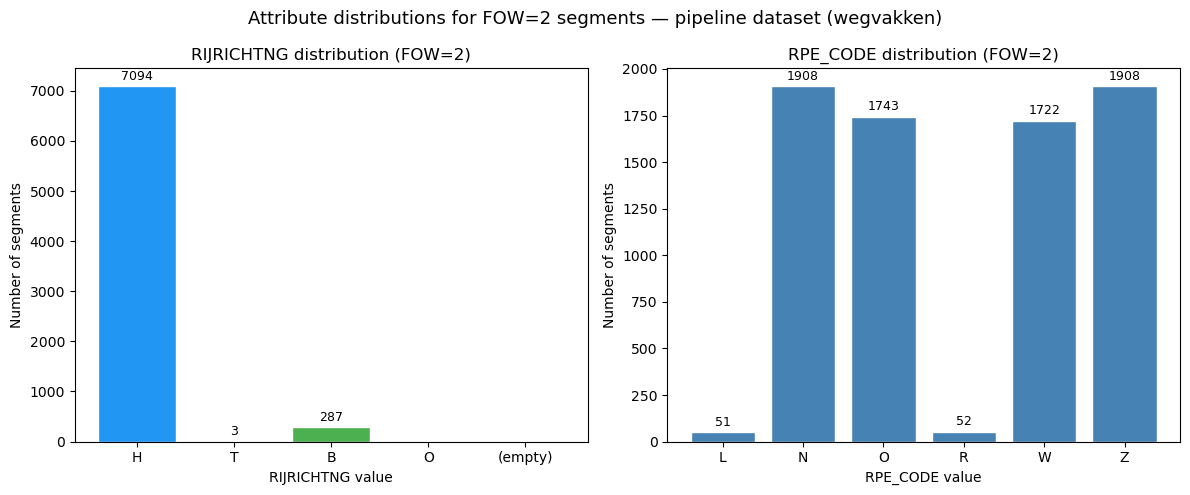

In [6]:
# Bar chart: distribution of RIJRICHTNG and RPE_CODE values for FOW=2 segments.
# Missing values are grouped under '(empty)' so they appear explicitly in the chart.

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Attribute distributions for FOW=2 segments — pipeline dataset (wegvakken)",
             fontsize=13)

# ---- RIJRICHTNG ----
rij_vals  = fow2["RIJRICHTNG"].fillna("(empty)").replace("", "(empty)")
rij_order = ["H", "T", "B", "O", "(empty)"]  # meaningful order
rij_counts = rij_vals.value_counts().reindex(rij_order, fill_value=0)

bar_colors_rij = [RIJRICHTNG_COLORS.get(v, COLOR_MISSING) for v in rij_counts.index]
axes[0].bar(rij_counts.index, rij_counts.values, color=bar_colors_rij, edgecolor="white")
axes[0].set_title("RIJRICHTNG distribution (FOW=2)")
axes[0].set_xlabel("RIJRICHTNG value")
axes[0].set_ylabel("Number of segments")
# Label each bar with its count
for i, v in enumerate(rij_counts.values):
    if v > 0:
        axes[0].text(i, v + max(rij_counts.values) * 0.01, str(v),
                     ha="center", va="bottom", fontsize=9)

# ---- RPE_CODE ----
rpe_vals   = fow2["RPE_CODE"].fillna("(empty)").replace("", "(empty)")
rpe_counts = rpe_vals.value_counts().sort_index()

axes[1].bar(rpe_counts.index, rpe_counts.values, color="steelblue", edgecolor="white")
axes[1].set_title("RPE_CODE distribution (FOW=2)")
axes[1].set_xlabel("RPE_CODE value")
axes[1].set_ylabel("Number of segments")
for i, v in enumerate(rpe_counts.values):
    if v > 0:
        axes[1].text(i, v + max(rpe_counts.values) * 0.01, str(v),
                     ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "exp_carriageway_attribute_distributions.png"),
            dpi=150, bbox_inches="tight")
plt.show()

## 3. Part 2 — Top-6 crowded intersections with FOW=2 connections

We want to find the busiest intersections (by raw road-segment count) that have at least
one FOW=2 segment attached. Then we map each one with:
- **Background:** all Rotterdam roads (`wegvakken_rot`) in light grey.
- **Foreground:** pipeline roads (`wegvakken`) coloured by `RIJRICHTNG`, labelled with `RPE_CODE`.

### 3a. Build junction → segment connection table

In [7]:
# Each wegvak has a BEG (start) and END junction.
# We 'melt' these into a long-form table so we can count segments per junction.

cols_needed = ["WVK_ID", "JTE_ID_BEG", "JTE_ID_END", "FOW_int", "RIJRICHTNG", "RPE_CODE"]
wvk_slim = wegvakken[cols_needed].copy()

beg = wvk_slim[["WVK_ID", "JTE_ID_BEG", "FOW_int"]].rename(columns={"JTE_ID_BEG": "JTE_ID"})
end = wvk_slim[["WVK_ID", "JTE_ID_END", "FOW_int"]].rename(columns={"JTE_ID_END": "JTE_ID"})
connections = pd.concat([beg, end], ignore_index=True)

# Keep only junctions that exist in our intersections dataset
# (i.e. ≥3 streets — the ones we care about for the photo pipeline).
jte_ids = set(intersections.index)
connections = connections[connections["JTE_ID"].isin(jte_ids)]

# Count unique segments per junction — used to rank by 'busyness'.
seg_count = connections.groupby("JTE_ID")["WVK_ID"].nunique().rename("seg_count")

# Flag junctions that have at least one FOW=2 segment attached.
has_fow2 = (
    connections[connections["FOW_int"] == 2]
    .groupby("JTE_ID")["WVK_ID"]
    .nunique() > 0
)

# Select top-6 junctions: must have FOW=2, ranked by total segment count.
fow2_junctions = has_fow2[has_fow2].index
top6_ids = seg_count.loc[seg_count.index.isin(fow2_junctions)].nlargest(6).index

print("Top-6 junctions (with FOW=2) by connected segment count:")
print(seg_count.loc[top6_ids].to_frame().assign(
    fow2_segs=connections[connections["FOW_int"] == 2]
              .groupby("JTE_ID")["WVK_ID"].nunique()
              .reindex(top6_ids)
))

Top-6 junctions (with FOW=2) by connected segment count:
           seg_count  fow2_segs
JTE_ID                         
186266081          6          4
186266101          6          6
187272022          6          4
177273174          5          4
178264100          5          4
178272015          5          2


### 3b. Map — one panel per intersection

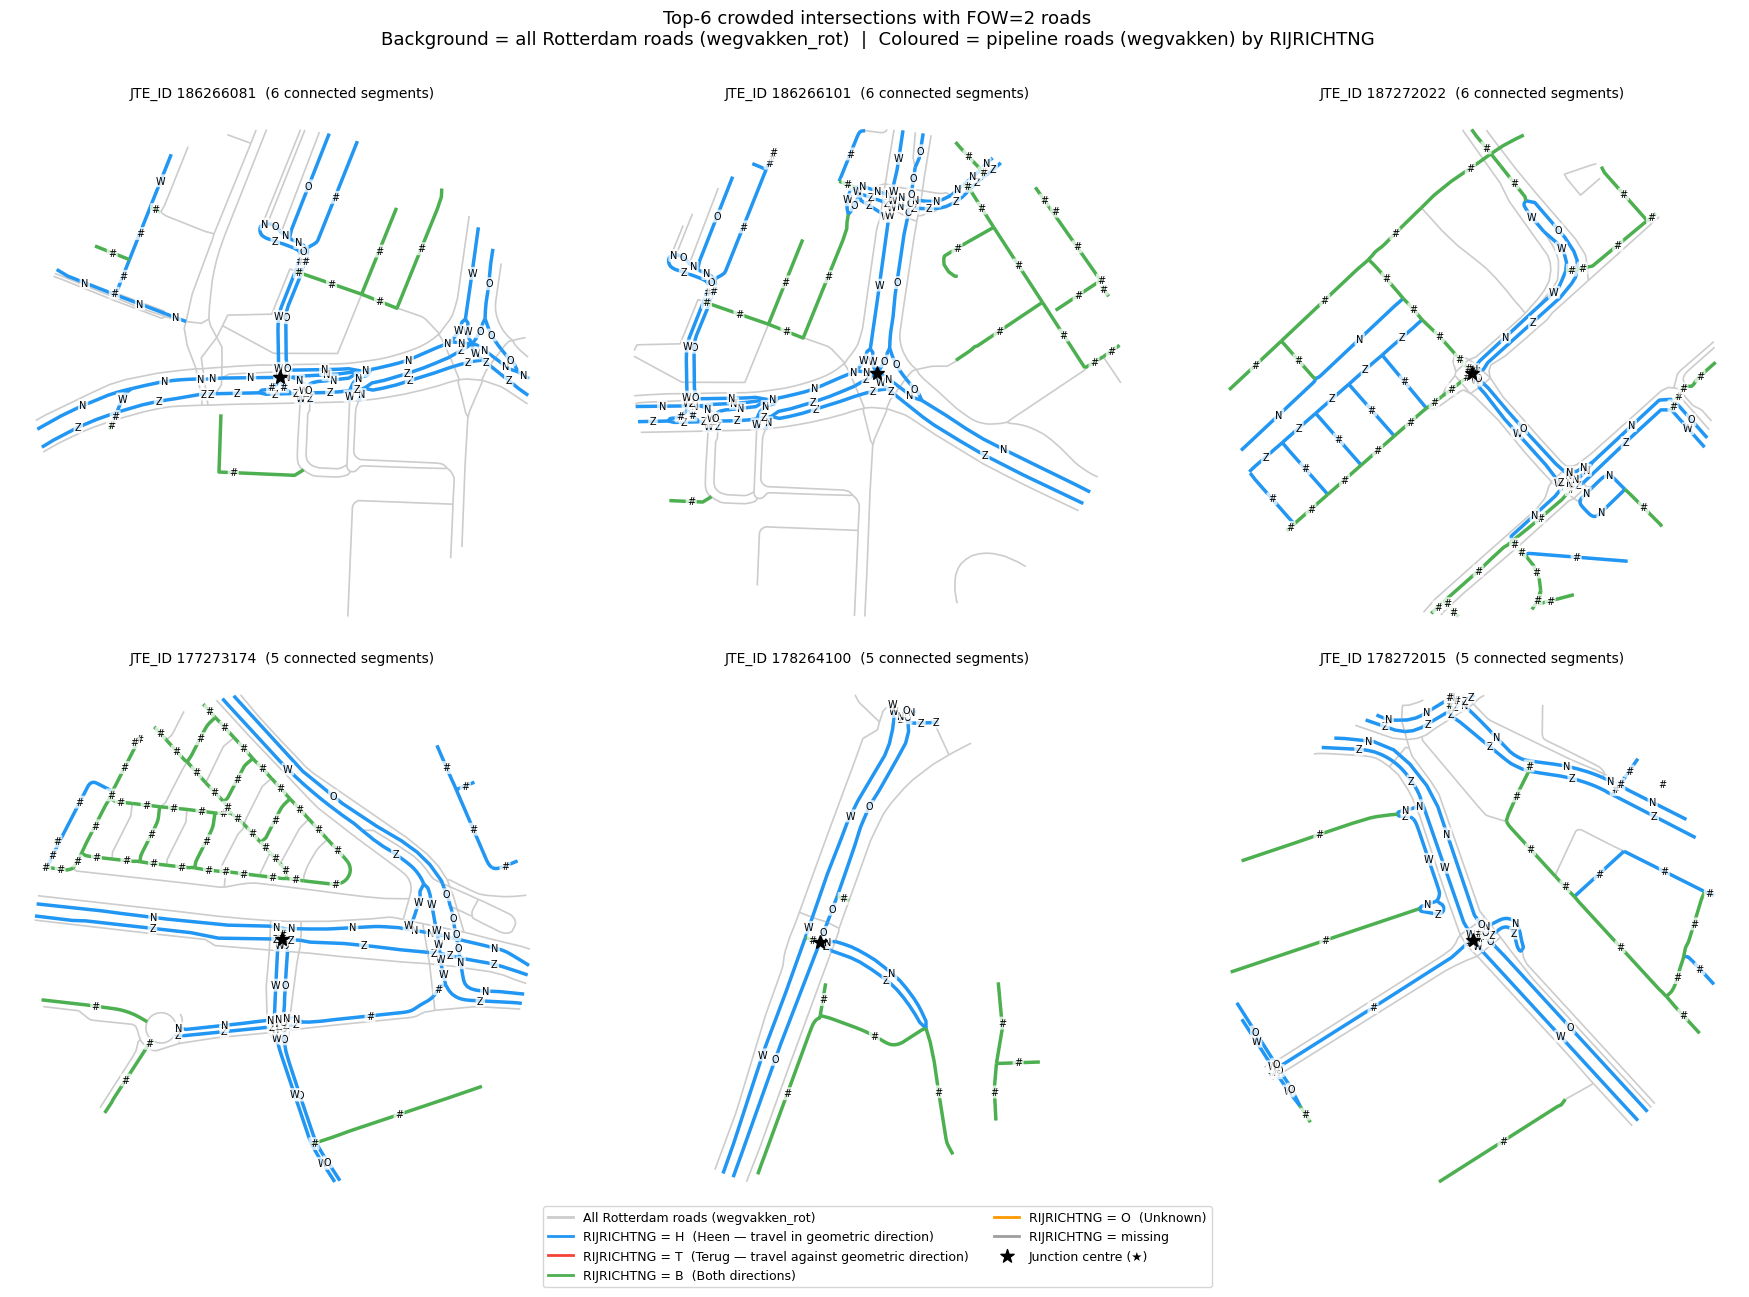

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle(
    "Top-6 crowded intersections with FOW=2 roads\n"
    "Background = all Rotterdam roads (wegvakken_rot)  |  "
    "Coloured = pipeline roads (wegvakken) by RIJRICHTNG",
    fontsize=13, y=1.01
)

for ax, jte_id in zip(axes.flat, top6_ids):

    # --- Define the map extent: circular buffer around the junction centre ---
    jte_geom = intersections.loc[jte_id, "geometry"]
    buf_geom  = jte_geom.buffer(BUFFER_M)
    buf_gdf   = gpd.GeoDataFrame(geometry=[buf_geom], crs=intersections.crs)

    # --- Clip both datasets to the buffer ---
    bg_clip = wegvakken_rot.clip(buf_gdf)   # all Rotterdam roads — background context
    fg_clip = wegvakken.clip(buf_gdf)       # pipeline roads — to be coloured

    # --- Plot background layer (wegvakken_rot) ---
    if not bg_clip.empty:
        bg_clip.plot(ax=ax, color=COLOR_BG_ROT, linewidth=1.2, zorder=1)

    # --- Plot pipeline roads (wegvakken) coloured by RIJRICHTNG ---
    # Group by RIJRICHTNG value so we can use a single .plot() call per colour
    # (much faster than plotting row-by-row).
    if not fg_clip.empty:
        fg_clip = fg_clip.copy()
        # Assign a colour to each segment based on its RIJRICHTNG value.
        fg_clip["_color"] = (
            fg_clip["RIJRICHTNG"]
            .map(RIJRICHTNG_COLORS)
            .fillna(COLOR_MISSING)
        )
        for color, group in fg_clip.groupby("_color"):
            group.plot(ax=ax, color=color, linewidth=2.5, zorder=2)

        # --- Add RPE_CODE labels at each segment's midpoint ---
        for _, seg in fg_clip.iterrows():
            rpe = str(seg.get("RPE_CODE", "") or "").strip()
            if not rpe or rpe == "nan":
                continue  # skip segments with no RPE_CODE — no label needed
            midpoint = seg.geometry.interpolate(0.5, normalized=True)
            ax.annotate(
                rpe,
                xy=(midpoint.x, midpoint.y),
                fontsize=7, ha="center", va="center", zorder=4,
                bbox=dict(boxstyle="round,pad=0.15", fc="white", alpha=0.75, ec="none"),
            )

    # --- Mark the junction centre ---
    ax.plot(jte_geom.x, jte_geom.y, "k*", markersize=10, zorder=5)

    n_segs  = seg_count.loc[jte_id]
    ax.set_title(f"JTE_ID {jte_id}  ({n_segs} connected segments)", fontsize=10)
    ax.set_axis_off()

# --- Shared legend ---
legend_elements = [
    Line2D([0], [0], color=COLOR_BG_ROT, linewidth=2,
           label="All Rotterdam roads (wegvakken_rot)"),
    Line2D([0], [0], color=RIJRICHTNG_COLORS["H"], linewidth=2,
           label="RIJRICHTNG = H  (Heen — travel in geometric direction)"),
    Line2D([0], [0], color=RIJRICHTNG_COLORS["T"], linewidth=2,
           label="RIJRICHTNG = T  (Terug — travel against geometric direction)"),
    Line2D([0], [0], color=RIJRICHTNG_COLORS["B"], linewidth=2,
           label="RIJRICHTNG = B  (Both directions)"),
    Line2D([0], [0], color=RIJRICHTNG_COLORS["O"], linewidth=2,
           label="RIJRICHTNG = O  (Unknown)"),
    Line2D([0], [0], color=COLOR_MISSING, linewidth=2,
           label="RIJRICHTNG = missing"),
    plt.scatter([], [], marker="*", c="black", s=100,
                label="Junction centre (★)"),
]
fig.legend(
    handles=legend_elements,
    loc="lower center", ncol=2, fontsize=9,
    bbox_to_anchor=(0.5, -0.06), frameon=True
)

plt.tight_layout()
plt.savefig(
    os.path.join(FIGURES_DIR, "exp_carriageway_top6_intersections.png"),
    dpi=150, bbox_inches="tight"
)
plt.show()

## 4. Part 3 — Attribute distributions across all gemeente segments (wegvakken_gemeente)

Unlike Part 1 which looked at FOW=2 only within the pipeline, this section shows how
`RIJRICHTNG` and `RPE_CODE` are distributed across **all** road types in the gemeente
dataset (no BST filter). This gives a broader baseline for comparison.

In [9]:
# Coverage summary: what fraction of all gemeente segments have each attribute filled?
# A value counts as 'filled' if it is non-null and non-empty after stripping whitespace.
wegvakken_gemeente_all = wegvakken_gemeente  # alias for clarity

rij_filled_g = is_filled(wegvakken_gemeente_all["RIJRICHTNG"])
rpe_filled_g = is_filled(wegvakken_gemeente_all["RPE_CODE"])

print(f"wegvakken_gemeente: {len(wegvakken_gemeente_all):,} total segments")
print(f"  FOW=2 (dual carriageway): {(wegvakken_gemeente_all['FOW_int'] == 2).sum():,}")
print(f"  FOW=3 (single carriageway): {(wegvakken_gemeente_all['FOW_int'] == 3).sum():,}")
print(f"\nRIJRICHTNG filled: {rij_filled_g.sum():,} / {len(wegvakken_gemeente_all):,} "
      f"({rij_filled_g.mean()*100:.1f}%)")
print(f"RPE_CODE   filled: {rpe_filled_g.sum():,} / {len(wegvakken_gemeente_all):,} "
      f"({rpe_filled_g.mean()*100:.1f}%)")

wegvakken_gemeente: 38,292 total segments
  FOW=2 (dual carriageway): 7,395
  FOW=3 (single carriageway): 17,973

RIJRICHTNG filled: 38,292 / 38,292 (100.0%)
RPE_CODE   filled: 38,292 / 38,292 (100.0%)


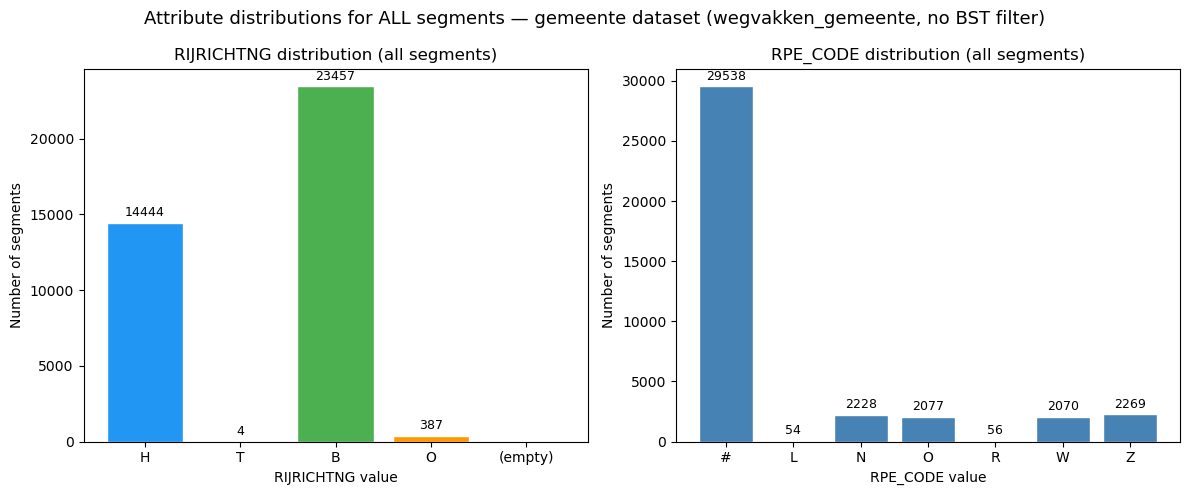

In [10]:
# Bar charts for ALL segments in wegvakken_gemeente — not filtered by FOW type.
# This gives a broader picture of how consistently RIJRICHTNG and RPE_CODE are populated
# across the full gemeente road network.

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(
    "Attribute distributions for ALL segments — gemeente dataset (wegvakken_gemeente, no BST filter)",
    fontsize=13
)

# ---- RIJRICHTNG ----
rij_vals_g  = wegvakken_gemeente["RIJRICHTNG"].fillna("(empty)").replace("", "(empty)")
rij_order   = ["H", "T", "B", "O", "(empty)"]
rij_counts_g = rij_vals_g.value_counts().reindex(rij_order, fill_value=0)

bar_colors_g = [RIJRICHTNG_COLORS.get(v, COLOR_MISSING) for v in rij_counts_g.index]
axes[0].bar(rij_counts_g.index, rij_counts_g.values, color=bar_colors_g, edgecolor="white")
axes[0].set_title("RIJRICHTNG distribution (all segments)")
axes[0].set_xlabel("RIJRICHTNG value")
axes[0].set_ylabel("Number of segments")
for i, v in enumerate(rij_counts_g.values):
    if v > 0:
        axes[0].text(i, v + max(rij_counts_g.values) * 0.01, str(v),
                     ha="center", va="bottom", fontsize=9)

# ---- RPE_CODE ----
rpe_vals_g   = wegvakken_gemeente["RPE_CODE"].fillna("(empty)").replace("", "(empty)")
rpe_counts_g = rpe_vals_g.value_counts().sort_index()

axes[1].bar(rpe_counts_g.index, rpe_counts_g.values, color="steelblue", edgecolor="white")
axes[1].set_title("RPE_CODE distribution (all segments)")
axes[1].set_xlabel("RPE_CODE value")
axes[1].set_ylabel("Number of segments")
for i, v in enumerate(rpe_counts_g.values):
    if v > 0:
        axes[1].text(i, v + max(rpe_counts_g.values) * 0.01, str(v),
                     ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig(
    os.path.join(FIGURES_DIR, "exp_carriageway_gemeente_attribute_distributions.png"),
    dpi=150, bbox_inches="tight"
)
plt.show()

## 5. Part 4 — Top-6 busiest intersections (all road types, wegvakken_gemeente)

Same visualisation approach as Part 2, but using the broader gemeente dataset:
- **Source:** `wegvakken_gemeente` (all gemeente roads, no BST restriction)
- **No FOW=2 requirement** — any intersection qualifies, ranked purely by segment count
- **Background:** `wegvakken_rot` (light grey)
- **Foreground:** `wegvakken_gemeente` roads coloured by `RIJRICHTNG`, labelled with `RPE_CODE`

Note: the junction set is still from `intersections.gpkg` (≥3 streets in the pipeline).
Segment counts are recomputed from `wegvakken_gemeente`, so they are generally higher than in Part 2.

### 5a. Build junction → segment connection table (gemeente)

In [11]:
# Build a long-form connection table from wegvakken_gemeente.
# Same melt approach as Part 2, but using the broader gemeente dataset (no BST restriction).

cols_g = ["WVK_ID", "JTE_ID_BEG", "JTE_ID_END", "FOW_int"]
wvk_g_slim = wegvakken_gemeente[cols_g].copy()

beg_g = wvk_g_slim[["WVK_ID", "JTE_ID_BEG", "FOW_int"]].rename(columns={"JTE_ID_BEG": "JTE_ID"})
end_g = wvk_g_slim[["WVK_ID", "JTE_ID_END", "FOW_int"]].rename(columns={"JTE_ID_END": "JTE_ID"})
connections_g = pd.concat([beg_g, end_g], ignore_index=True)

# Restrict to junctions that exist in our intersections dataset (≥3 streets in the pipeline).
# This means we only look at a subset of all gemeente junctions, but avoids computing new ones.
connections_g = connections_g[connections_g["JTE_ID"].isin(jte_ids)]

# Count unique segments per junction — all FOW types included.
seg_count_g = connections_g.groupby("JTE_ID")["WVK_ID"].nunique().rename("seg_count")

# Top-6 junctions by segment count, no FOW=2 filter.
top6_ids_g = seg_count_g.nlargest(6).index

print("Top-6 junctions (all road types) by connected segment count in wegvakken_gemeente:")
print(seg_count_g.loc[top6_ids_g].to_frame().assign(
    # Also show how many FOW=2 segments each junction has, for reference.
    fow2_segs=connections_g[connections_g["FOW_int"] == 2]
              .groupby("JTE_ID")["WVK_ID"].nunique()
              .reindex(top6_ids_g, fill_value=0)
))

Top-6 junctions (all road types) by connected segment count in wegvakken_gemeente:
           seg_count  fow2_segs
JTE_ID                         
183268071          7          4
189275019          7          2
186266081          6          4
186266101          6          6
186269044          6          2
187272022          6          4


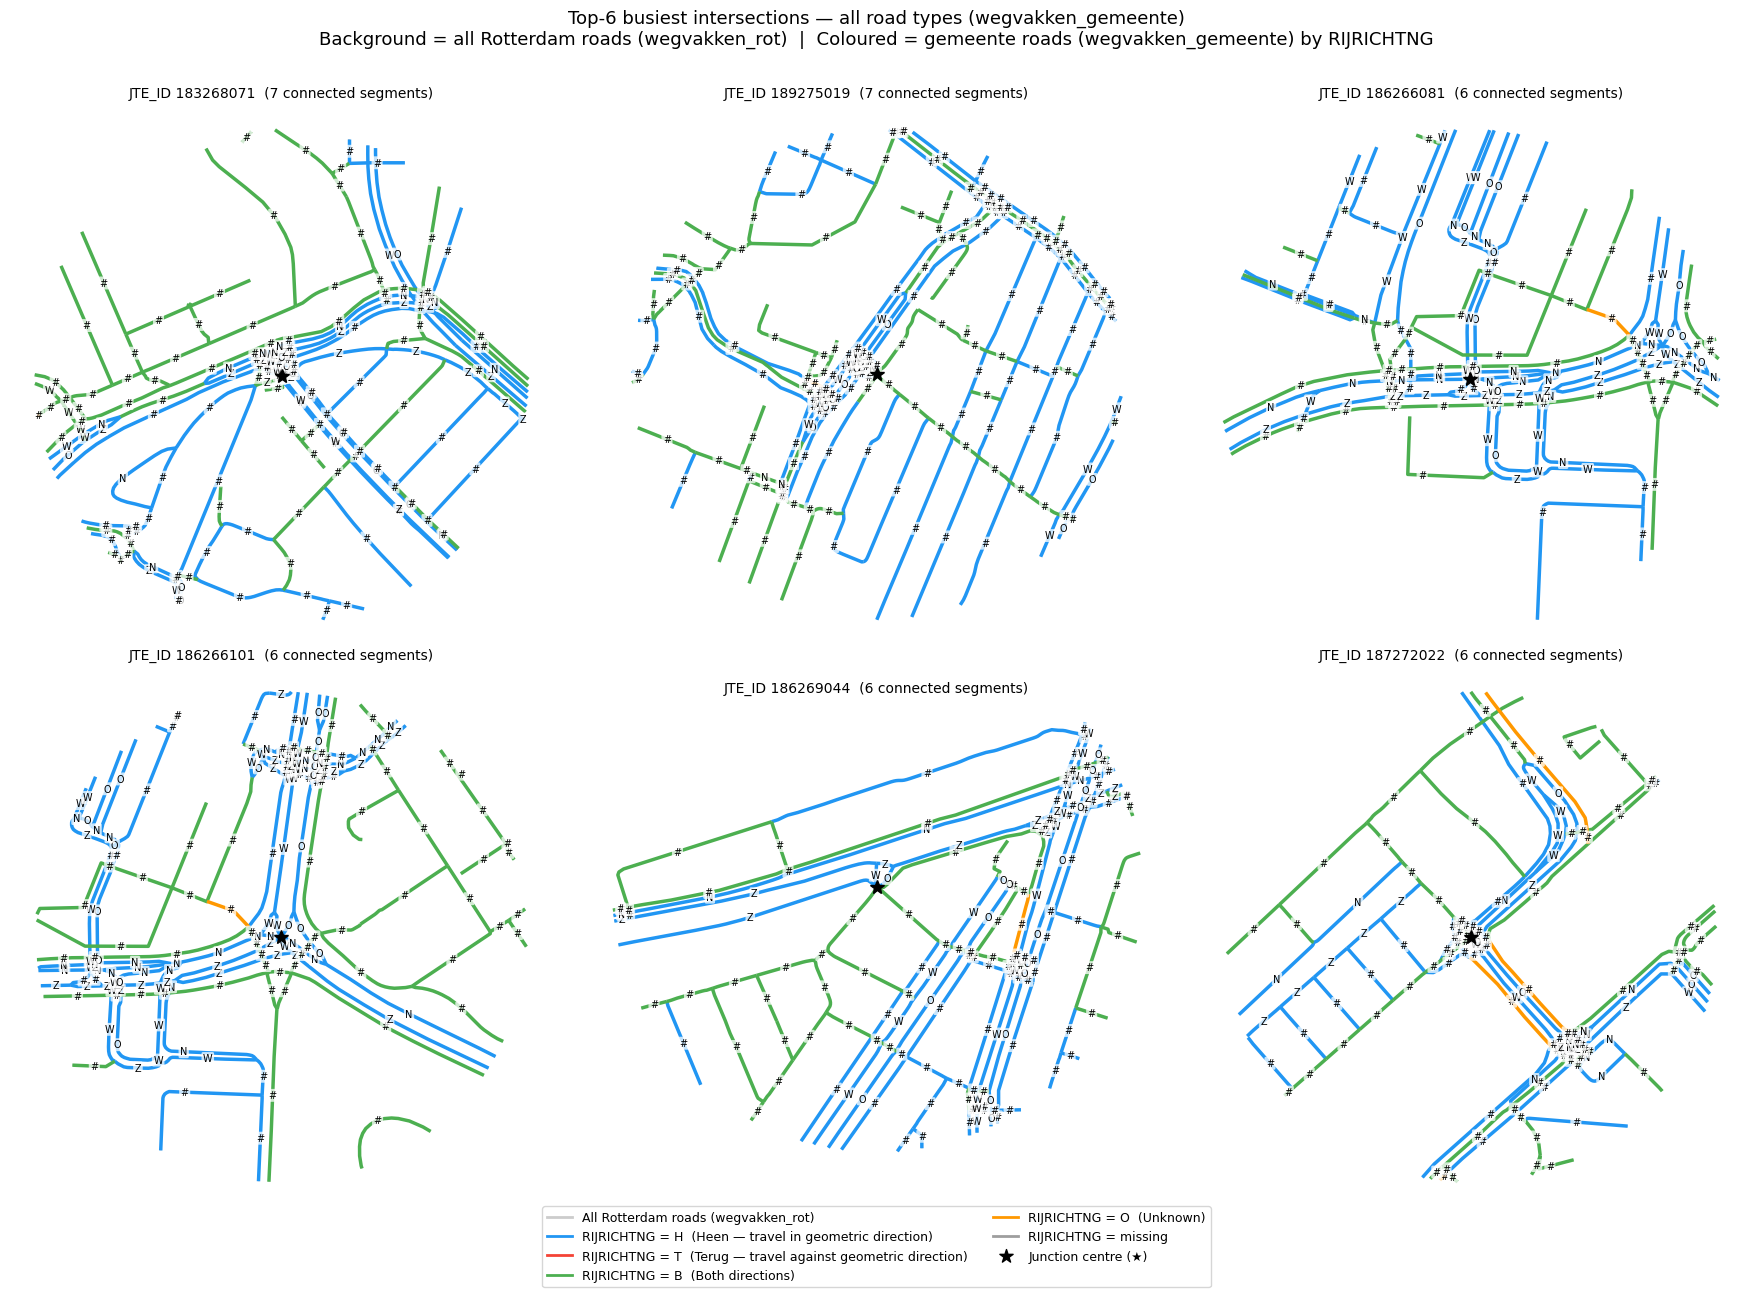

In [12]:
# Same visualisation structure as Part 2, but:
# - Foreground = wegvakken_gemeente (broader gemeente network, includes FOW=2 and all other types)
# - Top-6 selected without any FOW=2 requirement

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle(
    "Top-6 busiest intersections — all road types (wegvakken_gemeente)\n"
    "Background = all Rotterdam roads (wegvakken_rot)  |  "
    "Coloured = gemeente roads (wegvakken_gemeente) by RIJRICHTNG",
    fontsize=13, y=1.01
)

for ax, jte_id in zip(axes.flat, top6_ids_g):

    # Define map extent: buffer around the junction centre point.
    jte_geom = intersections.loc[jte_id, "geometry"]
    buf_geom  = jte_geom.buffer(BUFFER_M)
    buf_gdf   = gpd.GeoDataFrame(geometry=[buf_geom], crs=intersections.crs)

    # Clip both layers to the buffer area.
    bg_clip = wegvakken_rot.clip(buf_gdf)          # all Rotterdam — background context
    fg_clip = wegvakken_gemeente.clip(buf_gdf)     # gemeente roads — to be coloured

    # Background: all Rotterdam roads in light grey.
    if not bg_clip.empty:
        bg_clip.plot(ax=ax, color=COLOR_BG_ROT, linewidth=1.2, zorder=1)

    # Foreground: gemeente roads coloured by RIJRICHTNG.
    # Grouped .plot() calls are faster than row-by-row plotting.
    if not fg_clip.empty:
        fg_clip = fg_clip.copy()
        fg_clip["_color"] = (
            fg_clip["RIJRICHTNG"]
            .map(RIJRICHTNG_COLORS)
            .fillna(COLOR_MISSING)
        )
        for color, group in fg_clip.groupby("_color"):
            group.plot(ax=ax, color=color, linewidth=2.5, zorder=2)

        # RPE_CODE labels at each segment's midpoint.
        for _, seg in fg_clip.iterrows():
            rpe = str(seg.get("RPE_CODE", "") or "").strip()
            if not rpe or rpe == "nan":
                continue
            midpoint = seg.geometry.interpolate(0.5, normalized=True)
            ax.annotate(
                rpe,
                xy=(midpoint.x, midpoint.y),
                fontsize=7, ha="center", va="center", zorder=4,
                bbox=dict(boxstyle="round,pad=0.15", fc="white", alpha=0.75, ec="none"),
            )

    # Mark the junction centre.
    ax.plot(jte_geom.x, jte_geom.y, "k*", markersize=10, zorder=5)
    n_segs = seg_count_g.loc[jte_id]
    ax.set_title(f"JTE_ID {jte_id}  ({n_segs} connected segments)", fontsize=10)
    ax.set_axis_off()

# Shared legend for all panels.
legend_elements = [
    Line2D([0], [0], color=COLOR_BG_ROT, linewidth=2,
           label="All Rotterdam roads (wegvakken_rot)"),
    Line2D([0], [0], color=RIJRICHTNG_COLORS["H"], linewidth=2,
           label="RIJRICHTNG = H  (Heen — travel in geometric direction)"),
    Line2D([0], [0], color=RIJRICHTNG_COLORS["T"], linewidth=2,
           label="RIJRICHTNG = T  (Terug — travel against geometric direction)"),
    Line2D([0], [0], color=RIJRICHTNG_COLORS["B"], linewidth=2,
           label="RIJRICHTNG = B  (Both directions)"),
    Line2D([0], [0], color=RIJRICHTNG_COLORS["O"], linewidth=2,
           label="RIJRICHTNG = O  (Unknown)"),
    Line2D([0], [0], color=COLOR_MISSING, linewidth=2,
           label="RIJRICHTNG = missing"),
    plt.scatter([], [], marker="*", c="black", s=100,
                label="Junction centre (★)"),
]
fig.legend(
    handles=legend_elements,
    loc="lower center", ncol=2, fontsize=9,
    bbox_to_anchor=(0.5, -0.06), frameon=True
)

plt.tight_layout()
plt.savefig(
    os.path.join(FIGURES_DIR, "exp_carriageway_gemeente_top6_intersections.png"),
    dpi=150, bbox_inches="tight"
)
plt.show()

## 6. Part 5 — Approach classification using RIJRICHTNG

For each segment connected to a junction, we can determine whether traffic on that segment
is **approaching** or **exiting** the junction by combining two pieces of information:

1. **Which end of the segment is this junction?** (`JTE_ID_BEG` = geometric start, `JTE_ID_END` = geometric end)
2. **What is the allowed travel direction?** (`RIJRICHTNG`: H = Heen BEG→END, T = Terug END→BEG)

| Junction role | RIJRICHTNG | Classification |
|---|---|---|
| END of segment | H | **Approaching** — traffic arrives at junction |
| BEG of segment | T | **Approaching** — traffic arrives at junction |
| BEG of segment | H | **Exiting** — traffic leaves junction |
| END of segment | T | **Exiting** — traffic leaves junction |
| Either | B | **Two-way** — no forced direction |
| Either | O / missing | **Unknown** |

FOW=2 segments should always be classified as approaching or exiting (never two-way),
because separated carriageways always have a forced direction per NWB specification.

In [13]:
# Build a (junction, segment) connection table that includes:
# - which end of the segment this junction sits on (BEG or END)
# - RIJRICHTNG of the segment
# This is the core data needed to determine approach direction.

cols_approach = ["WVK_ID", "JTE_ID_BEG", "JTE_ID_END", "FOW_int", "RIJRICHTNG"]
wvk_ap = wegvakken[cols_approach].copy()

# Melt BEG and END into separate rows, recording which role each junction plays.
beg_ap = wvk_ap[["WVK_ID", "JTE_ID_BEG", "FOW_int", "RIJRICHTNG"]].copy()
beg_ap = beg_ap.rename(columns={"JTE_ID_BEG": "JTE_ID"})
beg_ap["junction_role"] = "BEG"   # this junction is the geometric start of the segment

end_ap = wvk_ap[["WVK_ID", "JTE_ID_END", "FOW_int", "RIJRICHTNG"]].copy()
end_ap = end_ap.rename(columns={"JTE_ID_END": "JTE_ID"})
end_ap["junction_role"] = "END"   # this junction is the geometric end of the segment

conn_approach = pd.concat([beg_ap, end_ap], ignore_index=True)
conn_approach = conn_approach[conn_approach["JTE_ID"].isin(jte_ids)]

# Apply the RIJRICHTNG classification rule.
#
# RIJRICHTNG = H (Heen): traffic moves BEG → END (in geometric direction).
#   - If junction is at END → traffic arrived here  → APPROACHING
#   - If junction is at BEG → traffic leaves here   → EXITING
#
# RIJRICHTNG = T (Terug): traffic moves END → BEG (against geometric direction).
#   - If junction is at BEG → traffic arrived here  → APPROACHING
#   - If junction is at END → traffic leaves here   → EXITING
#
# RIJRICHTNG = B (Beide): no forced direction → TWO-WAY (road is bidirectional)
# RIJRICHTNG = O / missing: direction unclear → UNKNOWN

def classify_approach(rij, role):
    if   rij == "H" and role == "END": return "approaching"
    elif rij == "T" and role == "BEG": return "approaching"
    elif rij == "H" and role == "BEG": return "exiting"
    elif rij == "T" and role == "END": return "exiting"
    elif rij == "B":                   return "two-way"
    else:                              return "unknown"

conn_approach["approach_status"] = conn_approach.apply(
    lambda r: classify_approach(r["RIJRICHTNG"], r["junction_role"]), axis=1
)

print(f"Connection rows classified: {len(conn_approach):,}")
print(conn_approach["approach_status"].value_counts().to_string())

Connection rows classified: 19,049
approach_status
two-way        9864
approaching    4597
exiting        4588


In [14]:
# Summary: how many approaching vs exiting segments per junction?
# And how does the classification break down by FOW type?

print("=== Approach classification summary (all pipeline intersections) ===\n")

# Overall counts
overall = conn_approach["approach_status"].value_counts()
print("All segments at all junctions:")
print(overall.to_string())
print()

# Break down by FOW type — useful to check whether FOW=2 is always classified
# (it should be, since RIJRICHTNG is mandatory for separated carriageways).
fow_breakdown = (
    conn_approach
    .groupby(["FOW_int", "approach_status"])["WVK_ID"]
    .count()
    .rename("count")
    .reset_index()
    .pivot(index="FOW_int", columns="approach_status", values="count")
    .fillna(0)
    .astype(int)
)
print("Breakdown by FOW type:")
print(fow_breakdown.to_string())
print()

# Sanity check: are there any FOW=2 segments classified as 'unknown' or 'two-way'?
# There should be none — FOW=2 always has a forced direction (H or T).
fow2_problems = conn_approach[
    (conn_approach["FOW_int"] == 2) &
    (conn_approach["approach_status"].isin(["unknown", "two-way"]))
]
print(f"FOW=2 segments with unexpected classification (should be 0): {len(fow2_problems)}")
if len(fow2_problems) > 0:
    print(fow2_problems[["WVK_ID", "JTE_ID", "RIJRICHTNG", "approach_status"]].head(10))

=== Approach classification summary (all pipeline intersections) ===

All segments at all junctions:
approach_status
two-way        9864
approaching    4597
exiting        4588

Breakdown by FOW type:
approach_status  approaching  exiting  two-way
FOW_int                                       
2                       2755     2745      182
3                       1828     1827     9610
7                         14       16       72

FOW=2 segments with unexpected classification (should be 0): 182
         WVK_ID     JTE_ID RIJRICHTNG approach_status
1591  186271092  186271066          B         two-way
1654  183274130  183274164          B         two-way
1664  180271157  180271191          B         two-way
1777  180271152  180271188          B         two-way
2035  600728356  185275110          B         two-way
3525  188274078  188274095          B         two-way
3849  600726984  183272084          B         two-way
4107  188274005  188274037          B         two-way
4173  600730

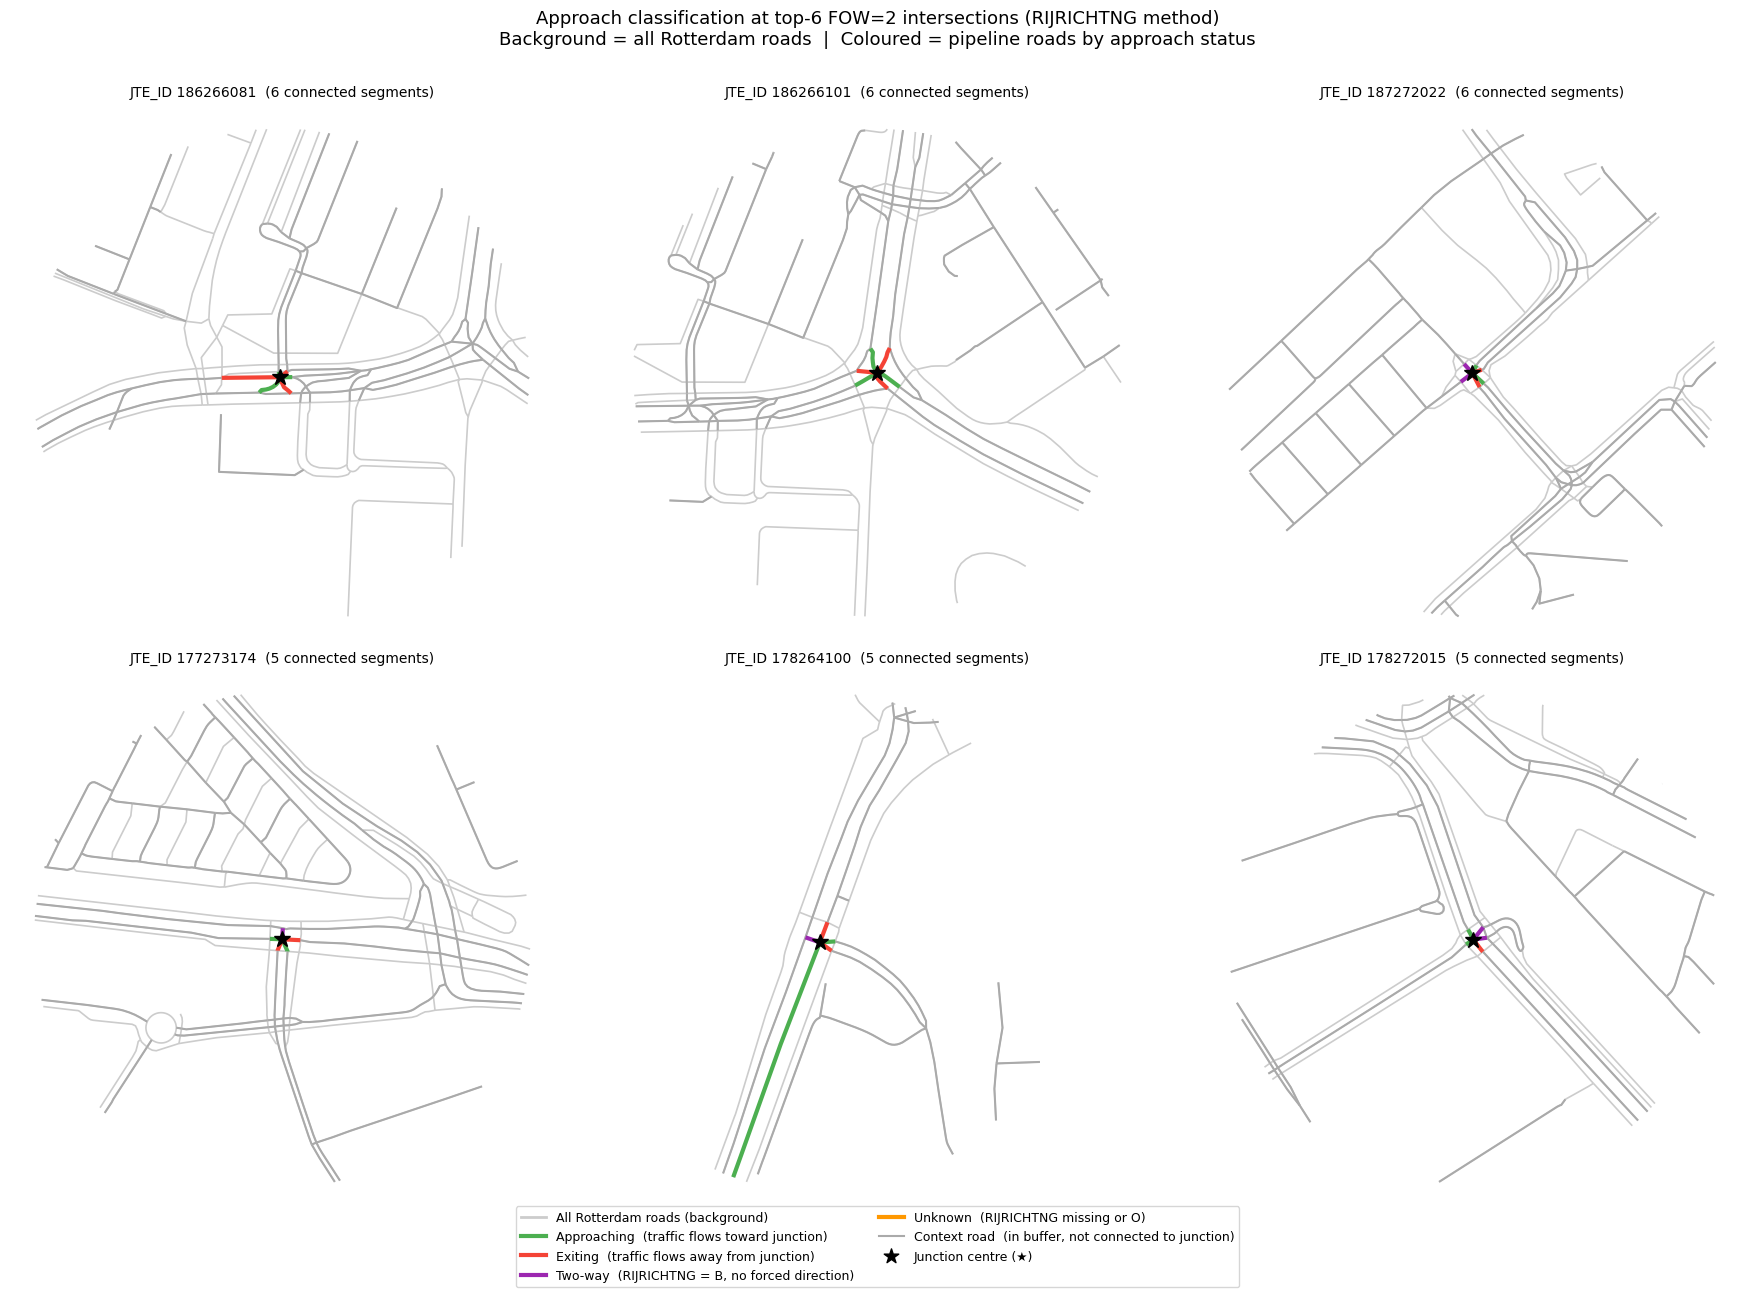

In [15]:
# Visualise approach classification for the top-6 FOW=2 intersections (from Part 2).
# Each segment connected to the junction is coloured by its approach status.
# Segments visible in the buffer but NOT connected to the junction are shown in a neutral grey.

APPROACH_COLORS = {
    "approaching": "#4CAF50",  # green  — traffic flows toward the junction
    "exiting":     "#F44336",  # red    — traffic flows away from the junction
    "two-way":     "#9C27B0",  # purple — no forced direction (RIJRICHTNG = B)
    "unknown":     "#FF9800",  # orange — RIJRICHTNG missing or O
    "context":     "#AAAAAA",  # grey   — road is in the buffer but not connected to this junction
}

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle(
    "Approach classification at top-6 FOW=2 intersections (RIJRICHTNG method)\n"
    "Background = all Rotterdam roads  |  Coloured = pipeline roads by approach status",
    fontsize=13, y=1.01
)

for ax, jte_id in zip(axes.flat, top6_ids):

    # Buffer around the junction centre.
    jte_geom = intersections.loc[jte_id, "geometry"]
    buf_geom  = jte_geom.buffer(BUFFER_M)
    buf_gdf   = gpd.GeoDataFrame(geometry=[buf_geom], crs=intersections.crs)

    # Clip both layers to the buffer.
    bg_clip = wegvakken_rot.clip(buf_gdf)
    fg_clip = wegvakken.clip(buf_gdf).copy()

    # Get the approach status for each segment connected to THIS junction.
    jte_status = (
        conn_approach[conn_approach["JTE_ID"] == jte_id]
        [["WVK_ID", "approach_status"]]
        .drop_duplicates("WVK_ID")  # each segment appears once per junction
    )

    # Merge status into the clipped foreground; segments not connected = "context".
    fg_clip = fg_clip.merge(jte_status, on="WVK_ID", how="left")
    fg_clip["approach_status"] = fg_clip["approach_status"].fillna("context")

    # Background: all Rotterdam roads in light grey.
    if not bg_clip.empty:
        bg_clip.plot(ax=ax, color=COLOR_BG_ROT, linewidth=1.2, zorder=1)

    # Foreground: pipeline roads coloured by approach status.
    # Context roads (not connected) drawn thinner so connected roads stand out.
    for status, group in fg_clip.groupby("approach_status"):
        lw    = 1.5 if status == "context" else 3.0
        color = APPROACH_COLORS.get(status, "#AAAAAA")
        group.plot(ax=ax, color=color, linewidth=lw, zorder=2 if status == "context" else 3)

    # Mark the junction centre.
    ax.plot(jte_geom.x, jte_geom.y, "k*", markersize=12, zorder=5)

    n_segs = seg_count.loc[jte_id]
    ax.set_title(f"JTE_ID {jte_id}  ({n_segs} connected segments)", fontsize=10)
    ax.set_axis_off()

# Shared legend.
legend_elements = [
    Line2D([0], [0], color=COLOR_BG_ROT,               linewidth=2, label="All Rotterdam roads (background)"),
    Line2D([0], [0], color=APPROACH_COLORS["approaching"], linewidth=3, label="Approaching  (traffic flows toward junction)"),
    Line2D([0], [0], color=APPROACH_COLORS["exiting"],     linewidth=3, label="Exiting  (traffic flows away from junction)"),
    Line2D([0], [0], color=APPROACH_COLORS["two-way"],     linewidth=3, label="Two-way  (RIJRICHTNG = B, no forced direction)"),
    Line2D([0], [0], color=APPROACH_COLORS["unknown"],     linewidth=3, label="Unknown  (RIJRICHTNG missing or O)"),
    Line2D([0], [0], color=APPROACH_COLORS["context"],     linewidth=1.5, label="Context road  (in buffer, not connected to junction)"),
    plt.scatter([], [], marker="*", c="black", s=120, label="Junction centre (★)"),
]
fig.legend(
    handles=legend_elements,
    loc="lower center", ncol=2, fontsize=9,
    bbox_to_anchor=(0.5, -0.06), frameon=True
)

plt.tight_layout()
plt.savefig(
    os.path.join(FIGURES_DIR, "exp_carriageway_approach_classification.png"),
    dpi=150, bbox_inches="tight"
)
plt.show()